# Doubling1D Animation

This notebook mirrors `L63_animation.ipynb`, but targets `dataset=doubling1d`.
It builds 2x2 prior/posterior comparison frames:

- top row: PF reference prior/posterior
- bottom row: selected method prior/posterior

It also exports percentile slices and a GIF over timesteps.


In [10]:
from pathlib import Path
import math
import os
import re
from typing import List, Tuple

from IPython.display import display
from PIL import Image, ImageDraw, ImageFont, ImageOps

# Bootstrap to project root
cwd = Path.cwd().resolve()
if cwd.name == 'test_notebooks':
    os.chdir(cwd.parent)
elif not (cwd / 'save').exists() and (cwd.parent / 'save').exists():
    os.chdir(cwd.parent)

PROJECT_ROOT = Path.cwd().resolve()
SAVE_DIR = PROJECT_ROOT / 'save'
OUTPUT_DIR = SAVE_DIR / 'figures' / 'doubling1d_animation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET = 'doubling1d'
assert DATASET == 'doubling1d'

# ---------------------------
# User config
# ---------------------------
METHOD_FAMILY = 'classic'   # 'train' or 'classic'
METHOD_NAME = 'EnKF'

ENSEMBLE_SIZE = 1000
STEP_START = 1
STEP_INTERVAL = 1
TRAJ_LEN = 200
STEP_END = TRAJ_LEN

FRAME_DURATION_MS = 200
SLICE_SUBDIR = 'slices'
SIGMA_Y = 0.2
PF_N = 1000000
PF_SEED = 42
TRAIN_SEED = 0
PF_INDEX_TAG = 'g0'
METHOD_INDEX_TAG = 'g0'
METHOD_RUN_TAG = 0
PF_TIMESTEP_OFFSET = -1  # PF timestep = method timestep - 1
PF_USE_NOHIST = True
FRAME_VARIANT = 'ring_pdf_on_ring_nohist'  # ring, ring_cdf, ring_pdf, ring_pdf_on_ring_nohist
IMAGE_CROP = {'left': 0.1, 'top': 0.05, 'right': 0.05, 'bottom': 0.1}
SKIP_MISSING_STEPS = False

BENCHMARK_METHODS = ['EnKF', 'ESRF', 'iEnKS-PertObs', 'iEnKS-Sqrt', 'iEnKS-Order1']
TRAINING_RESULTS_ROOT = SAVE_DIR / 'doubling1d_results'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUTPUT_DIR =', OUTPUT_DIR)
print('METHOD_FAMILY =', METHOD_FAMILY)
print('METHOD_NAME =', METHOD_NAME)
print('ENSEMBLE_SIZE =', ENSEMBLE_SIZE)
print('STEP config =', {'start': STEP_START, 'interval': STEP_INTERVAL, 'end': STEP_END})
print('FRAME_DURATION_MS =', FRAME_DURATION_MS)
print('FRAME_VARIANT =', FRAME_VARIANT)
print('IMAGE_CROP =', IMAGE_CROP)


PROJECT_ROOT = /home/bhchen/LearnKalmanGain
OUTPUT_DIR = /home/bhchen/LearnKalmanGain/save/figures/doubling1d_animation
METHOD_FAMILY = classic
METHOD_NAME = EnKF
ENSEMBLE_SIZE = 1000
STEP config = {'start': 1, 'interval': 1, 'end': 200}
FRAME_DURATION_MS = 200
FRAME_VARIANT = ring_pdf_on_ring_nohist
IMAGE_CROP = {'left': 0.1, 'top': 0.05, 'right': 0.05, 'bottom': 0.1}


In [11]:
RESAMPLING = getattr(Image, 'Resampling', Image).LANCZOS
TITLE_FONT_SIZE = 50
LABEL_FONT_SIZE = 36

VARIANT_SUFFIXES = {
    'ring': 'ring',
    'ring_cdf': 'ring_cdf',
    'ring_pdf': 'ring_pdf',
    'ring_pdf_on_ring_nohist': 'ring_pdf_on_ring_nohist',
}

TRAINING_MODEL_ORDER = {'ES': 0, 'NL2': 1}
TRAINING_LOSS_ORDER = {'EtE-LRes': 0, 'CorrTerms': 1}
COLUMN_LABELS = ('Prior', 'Posterior')
STAGE_TOKENS = {'prior': 'PRIOR', 'post': 'POST'}
SLICE_FRACTIONS = (0.25, 0.5, 0.75, 1.0)


def load_font(size: int):
    candidates = [
        '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
        '/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf',
    ]
    for font_path in candidates:
        try:
            return ImageFont.truetype(font_path, size=size)
        except OSError:
            continue
    return ImageFont.load_default()


def safe_slug(text: str) -> str:
    slug = re.sub(r'[^0-9a-zA-Z._-]+', '-', str(text)).strip('-').lower()
    return slug or 'item'


def pick_best_path(paths, preferred_tokens=None):
    preferred_tokens = preferred_tokens or []
    dedup = []
    seen = set()
    for p in paths:
        path_obj = Path(p)
        if path_obj in seen:
            continue
        seen.add(path_obj)
        dedup.append(path_obj)

    if not dedup:
        return None

    def score(path_obj: Path):
        text = str(path_obj)
        token_hits = sum(10 for token in preferred_tokens if token in text)
        return (token_hits, len(text))

    dedup.sort(key=score, reverse=True)
    return dedup[0]


def normalize_variant(frame_variant: str) -> str:
    frame_variant = str(frame_variant).strip()
    if frame_variant not in VARIANT_SUFFIXES:
        raise ValueError(f'Unsupported FRAME_VARIANT={frame_variant}. Available: {sorted(VARIANT_SUFFIXES)}')
    return frame_variant


def crop_image(img: Image.Image, crop: dict) -> Image.Image:
    crop = crop or {}
    left = float(crop.get('left', 0.0))
    top = float(crop.get('top', 0.0))
    right = float(crop.get('right', 0.0))
    bottom = float(crop.get('bottom', 0.0))

    if min(left, top, right, bottom) < 0:
        raise ValueError('Crop values must be >= 0.')
    if left + right >= 1 or top + bottom >= 1:
        raise ValueError('Crop fractions must leave a positive area.')

    width, height = img.size
    x0 = int(round(width * left))
    y0 = int(round(height * top))
    x1 = width - int(round(width * right))
    y1 = height - int(round(height * bottom))
    return img.crop((x0, y0, x1, y1))


def parse_training_folder(folder_name: str):
    match = re.search(r'_(?P<model>es|nl2)_joint_(?P<loss>[^_/]+)None_(?P<obs_fn>[^_/]+)$', folder_name)
    if not match:
        return None
    return {
        'model': match.group('model').upper(),
        'loss': match.group('loss').replace('None', '').strip('_'),
        'obs_fn': match.group('obs_fn'),
    }


def has_training_artifacts(folder: Path) -> bool:
    patterns = [
        'output_records_*.pt',
        'cp_*.pth',
        'test_*_g0_slice_step*_0_ring*.png',
    ]
    if (folder / 'figures').exists():
        return True
    return any(any(folder.glob(pattern)) for pattern in patterns)


def discover_training_specs():
    if (not TRAINING_RESULTS_ROOT.exists()) or (not TRAINING_RESULTS_ROOT.is_dir()):
        return []

    specs = []
    for run_dir in sorted(TRAINING_RESULTS_ROOT.iterdir()):
        if (not run_dir.is_dir()) or (not has_training_artifacts(run_dir)):
            continue
        meta = parse_training_folder(run_dir.name)
        if meta is None:
            continue
        if meta['model'] not in TRAINING_MODEL_ORDER or meta['loss'] not in TRAINING_LOSS_ORDER:
            continue
        specs.append({
            'label': f"Train-{meta['model']}-{meta['loss']}",
            'dir': run_dir,
            'family': 'train',
            'model': meta['model'],
            'loss': meta['loss'],
            'obs_fn': meta['obs_fn'],
        })

    specs.sort(
        key=lambda spec: (
            TRAINING_LOSS_ORDER[spec['loss']],
            TRAINING_MODEL_ORDER[spec['model']],
            spec['dir'].name,
        )
    )
    return specs


def discover_benchmark_specs():
    specs = []
    for method in BENCHMARK_METHODS:
        run_dir = SAVE_DIR / f'benchmark_doubling1d_{SIGMA_Y}_{method}'
        if run_dir.exists():
            specs.append({
                'label': f'Classic-{method}',
                'dir': run_dir,
                'family': 'classic',
                'method': method,
            })
    return specs


def get_available_specs(method_family: str):
    method_family = str(method_family).strip().lower()
    if method_family == 'train':
        return discover_training_specs()
    if method_family == 'classic':
        return discover_benchmark_specs()
    raise ValueError("method_family must be 'train' or 'classic'.")


def list_available_methods(method_family: str):
    specs = get_available_specs(method_family)
    print(f'Available trials for method_family={method_family}:')
    for spec in specs:
        extra = ''
        if spec['family'] == 'train':
            extra = f" | obs_fn={spec['obs_fn']}"
        print(' -', spec['label'], '|', spec['dir'], extra)
    return specs


def resolve_method_spec(method_family: str, method_name: str):
    method_family = str(method_family).strip().lower()
    method_name = str(method_name).strip()
    specs = get_available_specs(method_family)

    aliases = {spec['label']: spec for spec in specs}
    if method_family == 'classic':
        for spec in specs:
            aliases[spec['label'].replace('Classic-', '')] = spec

    if method_name in aliases:
        return aliases[method_name]

    partial = [spec for spec in specs if method_name.lower() in spec['label'].lower()]
    if len(partial) == 1:
        return partial[0]
    if len(partial) > 1:
        raise ValueError(f'Ambiguous method_name={method_name}. Matches: {[spec["label"] for spec in partial]}')

    raise ValueError(
        f'Could not resolve method_name={method_name} for family={method_family}. '
        f'Available: {[spec["label"] for spec in specs]}'
    )


def iter_method_image_dirs(method_dir: Path):
    candidates = [method_dir / 'figures', method_dir]
    out = []
    seen = set()
    for cand in candidates:
        if cand in seen:
            continue
        seen.add(cand)
        if cand.exists():
            out.append(cand)
    return out


def get_pf_vis_dir() -> Path:
    pf_dir = SAVE_DIR / 'doubling1d_pf_vis'
    if not pf_dir.exists():
        raise FileNotFoundError(f'Missing PF visualization directory: {pf_dir}')
    return pf_dir


def build_step_values(start: int, interval: int, end: int):
    start = int(start)
    interval = int(interval)
    end = int(end)
    if start < 1:
        raise ValueError('STEP_START must be >= 1.')
    if interval < 1:
        raise ValueError('STEP_INTERVAL must be >= 1.')
    if end < start:
        raise ValueError('STEP_END must be >= STEP_START.')
    return list(range(start, end + 1, interval))


def fit_to_tile(img: Image.Image, tile_size: Tuple[int, int]) -> Image.Image:
    canvas = Image.new('RGB', tile_size, (255, 255, 255))
    contained = ImageOps.contain(img.convert('RGB'), tile_size, method=RESAMPLING)
    x = (tile_size[0] - contained.width) // 2
    y = (tile_size[1] - contained.height) // 2
    canvas.paste(contained, (x, y))
    return canvas


def load_processed_image(image_path: Path, crop: dict) -> Image.Image:
    with Image.open(image_path) as img:
        return crop_image(img.convert('RGB'), crop)


def extract_step_from_name(name: str, token: str):
    match = re.search(rf'{token}(\d+)', name)
    if not match:
        return None
    return int(match.group(1))


def method_step_to_pf_step(method_step: int) -> int:
    return int(method_step) + int(PF_TIMESTEP_OFFSET)


def pf_step_to_method_step(pf_step: int) -> int:
    return int(pf_step) - int(PF_TIMESTEP_OFFSET)


def find_pf_image(step: int, stage: str, frame_variant: str, pf_dir: Path):
    pf_step = method_step_to_pf_step(step)
    if pf_step < 0:
        return None

    stage_token = STAGE_TOKENS[stage]
    if PF_USE_NOHIST:
        stage_token = f'{stage_token}_nohist'
    variant_suffix = VARIANT_SUFFIXES[normalize_variant(frame_variant)]
    candidates = list(pf_dir.glob(
        f'sigma_y{SIGMA_Y}_batch64_len{TRAJ_LEN}_pfN*_timestep{pf_step}_*_{PF_INDEX_TAG}_{stage_token}_0_{variant_suffix}.png'
    ))
    preferred = [f'pfN{PF_N}', f'_{PF_SEED}_', f'_{stage_token}_0_{variant_suffix}.png']
    return pick_best_path(candidates, preferred_tokens=preferred)


def find_method_image(step: int, stage: str, frame_variant: str, ensemble_size: int, method_spec: dict):
    variant_suffix = VARIANT_SUFFIXES[normalize_variant(frame_variant)]
    stage_patterns = []
    if method_spec['family'] == 'classic':
        stage_token = 'classic_prior' if stage == 'prior' else 'classic'
        stage_patterns.extend([
            f'test_{ensemble_size}_0_{stage_token}_{METHOD_INDEX_TAG}_slice_step{step}_{METHOD_RUN_TAG}_{variant_suffix}.png',
            f'test_{ensemble_size}_0_{stage_token}_{METHOD_INDEX_TAG}_slice_step{step}_*_{variant_suffix}.png',
        ])
    else:
        prefix = f'test_{ensemble_size}_{TRAIN_SEED}'
        if stage == 'prior':
            prefix += '_prior'
        stage_patterns.extend([
            f'{prefix}_{METHOD_INDEX_TAG}_slice_step{step}_{METHOD_RUN_TAG}_{variant_suffix}.png',
            f'{prefix}_{METHOD_INDEX_TAG}_slice_step{step}_*_{variant_suffix}.png',
        ])

    candidates = []
    for image_dir in iter_method_image_dirs(method_spec['dir']):
        for pattern in stage_patterns:
            candidates.extend(image_dir.glob(pattern))

    preferred = [
        f'test_{ensemble_size}_',
        f'slice_step{step}_{METHOD_RUN_TAG}_{variant_suffix}.png',
    ]
    if method_spec['family'] == 'classic':
        preferred.append('classic_prior' if stage == 'prior' else 'classic')
    return pick_best_path(candidates, preferred_tokens=preferred)


def collect_pf_steps(frame_variant: str, pf_dir: Path):
    variant_suffix = VARIANT_SUFFIXES[normalize_variant(frame_variant)]
    stage_steps = []
    for stage_token in STAGE_TOKENS.values():
        if PF_USE_NOHIST:
            stage_token = f'{stage_token}_nohist'
        steps = set()
        pattern = f'sigma_y{SIGMA_Y}_batch64_len{TRAJ_LEN}_pfN*_timestep*_*_{PF_INDEX_TAG}_{stage_token}_0_{variant_suffix}.png'
        for path in pf_dir.glob(pattern):
            pf_step = extract_step_from_name(path.name, 'timestep')
            if pf_step is not None:
                method_step = pf_step_to_method_step(pf_step)
                if method_step >= 1:
                    steps.add(method_step)
        stage_steps.append(steps)
    return set.intersection(*stage_steps) if stage_steps else set()


def collect_method_steps(frame_variant: str, ensemble_size: int, method_spec: dict):
    variant_suffix = VARIANT_SUFFIXES[normalize_variant(frame_variant)]
    stage_patterns = []
    if method_spec['family'] == 'classic':
        stage_patterns = [
            f'test_{ensemble_size}_0_classic_prior_{METHOD_INDEX_TAG}_slice_step*_*_{variant_suffix}.png',
            f'test_{ensemble_size}_0_classic_{METHOD_INDEX_TAG}_slice_step*_*_{variant_suffix}.png',
        ]
    else:
        stage_patterns = [
            f'test_{ensemble_size}_{TRAIN_SEED}_prior_{METHOD_INDEX_TAG}_slice_step*_*_{variant_suffix}.png',
            f'test_{ensemble_size}_{TRAIN_SEED}_{METHOD_INDEX_TAG}_slice_step*_*_{variant_suffix}.png',
        ]

    stage_steps = []
    for pattern in stage_patterns:
        steps = set()
        for image_dir in iter_method_image_dirs(method_spec['dir']):
            for path in image_dir.glob(pattern):
                step = extract_step_from_name(path.name, 'slice_step')
                if step is not None:
                    steps.add(step)
        stage_steps.append(steps)
    return set.intersection(*stage_steps) if stage_steps else set()


def get_effective_step_values(frame_variant: str, pf_dir: Path, method_spec: dict, ensemble_size: int):
    requested_steps = build_step_values(STEP_START, STEP_INTERVAL, STEP_END)
    pf_steps = collect_pf_steps(frame_variant, pf_dir)
    method_steps = collect_method_steps(frame_variant, ensemble_size, method_spec)
    common_steps = [step for step in requested_steps if step in pf_steps and step in method_steps]

    if not common_steps:
        raise FileNotFoundError(
            'No common steps found between PF and method images for the current config. '
            f'Requested range={requested_steps[:3]}...{requested_steps[-3:]}, '
            f'pf_count={len(pf_steps)}, method_count={len(method_steps)}'
        )

    if common_steps != requested_steps:
        print(
            'Using common available steps only:',
            {'requested_start': requested_steps[0], 'requested_end': requested_steps[-1],
             'effective_start': common_steps[0], 'effective_end': common_steps[-1],
             'effective_count': len(common_steps)}
        )
    return common_steps


def load_frame_images(step: int, frame_variant: str, pf_dir: Path, method_spec: dict, ensemble_size: int):
    pf_paths = {}
    method_paths = {}
    missing = []

    for stage in ('prior', 'post'):
        pf_path = find_pf_image(step=step, stage=stage, frame_variant=frame_variant, pf_dir=pf_dir)
        method_path = find_method_image(
            step=step,
            stage=stage,
            frame_variant=frame_variant,
            ensemble_size=ensemble_size,
            method_spec=method_spec,
        )
        if pf_path is None:
            missing.append(f'PF:{stage}')
        else:
            pf_paths[stage] = pf_path
        if method_path is None:
            missing.append(f'METHOD:{stage}')
        else:
            method_paths[stage] = method_path

    if missing:
        raise FileNotFoundError(f'Missing images at step={step}, variant={frame_variant}: {missing}')

    return pf_paths, method_paths


def compose_grid_frame(step: int, frame_variant: str, pf_dir: Path, method_spec: dict, ensemble_size: int):
    pf_paths, method_paths = load_frame_images(
        step=step,
        frame_variant=frame_variant,
        pf_dir=pf_dir,
        method_spec=method_spec,
        ensemble_size=ensemble_size,
    )

    loaded_tiles = []
    try:
        for path in [pf_paths['prior'], pf_paths['post'], method_paths['prior'], method_paths['post']]:
            loaded_tiles.append(load_processed_image(path, IMAGE_CROP))

        tile_w = max(im.width for im in loaded_tiles)
        tile_h = max(im.height for im in loaded_tiles)
        tile_size = (tile_w, tile_h)

        pad = 14
        title_h = 82
        header_h = 60
        row_label_w = 120
        canvas_w = row_label_w + pad * 3 + tile_w * 2
        canvas_h = title_h + header_h + pad * 3 + tile_h * 2
        canvas = Image.new('RGB', (canvas_w, canvas_h), (255, 255, 255))
        draw = ImageDraw.Draw(canvas)
        title_font = load_font(TITLE_FONT_SIZE)
        header_font = load_font(LABEL_FONT_SIZE)
        row_font = load_font(LABEL_FONT_SIZE)

        title = f'{DATASET} | {safe_slug(method_spec["label"])} | N={ensemble_size} | timestep={step}'
        title_bbox = draw.textbbox((0, 0), title, font=title_font)
        title_w = title_bbox[2] - title_bbox[0]
        title_x = max(pad, (canvas_w - title_w) // 2)
        title_y = max(pad, (title_h - (title_bbox[3] - title_bbox[1])) // 2)
        draw.text((title_x, title_y), title, font=title_font, fill=(0, 0, 0))

        x_tiles_origin = row_label_w + pad
        y_header = title_h
        for col, col_label in enumerate(COLUMN_LABELS):
            bbox = draw.textbbox((0, 0), col_label, font=header_font)
            label_w = bbox[2] - bbox[0]
            x0 = x_tiles_origin + col * (tile_w + pad)
            draw.text(
                (x0 + (tile_w - label_w) // 2, y_header + (header_h - (bbox[3] - bbox[1])) // 2),
                col_label,
                font=header_font,
                fill=(0, 0, 0),
            )

        row_labels = ('Truth', method_spec['label'].replace('Classic-', '').replace('Train-', ''))
        y_tiles_origin = title_h + header_h + pad
        for row, row_label in enumerate(row_labels):
            bbox = draw.textbbox((0, 0), row_label, font=row_font)
            label_w = bbox[2] - bbox[0]
            label_h = bbox[3] - bbox[1]
            row_y = y_tiles_origin + row * (tile_h + pad)
            draw.text(
                (max(pad, row_label_w - label_w - pad), row_y + (tile_h - label_h) // 2),
                row_label,
                font=row_font,
                fill=(0, 0, 0),
            )

        tile_map = {
            (0, 0): loaded_tiles[0],
            (0, 1): loaded_tiles[1],
            (1, 0): loaded_tiles[2],
            (1, 1): loaded_tiles[3],
        }
        for row in range(2):
            for col in range(2):
                tile = fit_to_tile(tile_map[(row, col)], tile_size)
                x0 = x_tiles_origin + col * (tile_w + pad)
                y0 = y_tiles_origin + row * (tile_h + pad)
                canvas.paste(tile, (x0, y0))

        return canvas
    finally:
        for im in loaded_tiles:
            try:
                im.close()
            except Exception:
                pass


def save_gif(frames: List[Image.Image], gif_path: Path, duration_ms: int):
    if not frames:
        raise ValueError('No frames to save.')
    gif_path.parent.mkdir(parents=True, exist_ok=True)
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=duration_ms,
        loop=0,
    )


def select_slice_steps(used_steps: List[int], fractions=SLICE_FRACTIONS):
    if not used_steps:
        raise ValueError('used_steps must not be empty.')

    total = len(used_steps)
    slice_specs = []
    for frac in fractions:
        idx = min(total - 1, max(0, math.ceil(total * float(frac)) - 1))
        slice_specs.append({
            'fraction': float(frac),
            'percent_label': f"{int(round(float(frac) * 100))}%",
            'percent_tag': f"{int(round(float(frac) * 100))}pct",
            'index': idx,
            'step': used_steps[idx],
        })
    return slice_specs


def build_output_stem(method_spec: dict, ensemble_size: int, frame_variant: str, used_steps: List[int]):
    return (
        f'doubling1d_{safe_slug(method_spec["label"])}'
        f'_N{ensemble_size}_{safe_slug(frame_variant)}_steps{used_steps[0]}-{used_steps[-1]}'
    )


def save_slice_grid(frames: List[Image.Image], grid_path: Path):
    if not frames:
        raise ValueError('frames must not be empty.')

    tile_w = max(frame.width for frame in frames)
    tile_h = max(frame.height for frame in frames)
    pad = 12
    cols = 2
    rows = 2
    canvas_w = pad * (cols + 1) + tile_w * cols
    canvas_h = pad * (rows + 1) + tile_h * rows
    canvas = Image.new('RGB', (canvas_w, canvas_h), (255, 255, 255))

    for idx, frame in enumerate(frames):
        row = idx // cols
        col = idx % cols
        x0 = pad + col * (tile_w + pad)
        y0 = pad + row * (tile_h + pad)
        canvas.paste(fit_to_tile(frame, (tile_w, tile_h)), (x0, y0))

    grid_path.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(grid_path)


def build_slice_previews(method_spec=None, fractions=SLICE_FRACTIONS):
    method_spec = method_spec or resolve_method_spec(METHOD_FAMILY, METHOD_NAME)
    pf_dir = get_pf_vis_dir()
    used_steps = get_effective_step_values(FRAME_VARIANT, pf_dir, method_spec, ENSEMBLE_SIZE)
    slice_specs = select_slice_steps(used_steps, fractions=fractions)
    output_stem = build_output_stem(method_spec, ENSEMBLE_SIZE, FRAME_VARIANT, used_steps)
    slice_dir = OUTPUT_DIR / SLICE_SUBDIR

    frames = []
    image_paths = []
    try:
        for spec in slice_specs:
            frame = compose_grid_frame(
                step=spec['step'],
                frame_variant=FRAME_VARIANT,
                pf_dir=pf_dir,
                method_spec=method_spec,
                ensemble_size=ENSEMBLE_SIZE,
            )
            frames.append(frame)
            image_path = slice_dir / f"{output_stem}_{spec['percent_tag']}_step{spec['step']}.png"
            slice_dir.mkdir(parents=True, exist_ok=True)
            frame.save(image_path)
            image_paths.append(image_path)

        grid_path = slice_dir / f'{output_stem}_grid.png'
        save_slice_grid(frames, grid_path)
        return {
            'grid_path': grid_path,
            'image_paths': image_paths,
            'slice_steps': [spec['step'] for spec in slice_specs],
            'slice_labels': [spec['percent_label'] for spec in slice_specs],
        }
    finally:
        for frame in frames:
            try:
                frame.close()
            except Exception:
                pass


def build_animation(method_spec=None):
    method_spec = method_spec or resolve_method_spec(METHOD_FAMILY, METHOD_NAME)
    pf_dir = get_pf_vis_dir()
    step_values = get_effective_step_values(FRAME_VARIANT, pf_dir, method_spec, ENSEMBLE_SIZE)

    frames = []
    used_steps = []
    missing_errors = []

    for step in step_values:
        try:
            frame = compose_grid_frame(
                step=step,
                frame_variant=FRAME_VARIANT,
                pf_dir=pf_dir,
                method_spec=method_spec,
                ensemble_size=ENSEMBLE_SIZE,
            )
            frames.append(frame)
            used_steps.append(step)
        except FileNotFoundError as exc:
            if SKIP_MISSING_STEPS:
                print('[skip]', exc)
                continue
            missing_errors.append(str(exc))
            break

    if missing_errors:
        raise FileNotFoundError(missing_errors[0])
    if not frames:
        raise RuntimeError('No frames were created. Check paths/config.')

    output_stem = build_output_stem(method_spec, ENSEMBLE_SIZE, FRAME_VARIANT, used_steps)
    gif_path = OUTPUT_DIR / f'{output_stem}.gif'
    save_gif(frames, gif_path, FRAME_DURATION_MS)
    return {
        'gif_path': gif_path,
        'used_steps': used_steps,
        'pf_dir': pf_dir,
        'method_spec': method_spec,
    }


In [12]:
available_specs = list_available_methods(METHOD_FAMILY)


Available trials for method_family=classic:
 - Classic-EnKF | /home/bhchen/LearnKalmanGain/save/benchmark_doubling1d_0.2_EnKF 
 - Classic-ESRF | /home/bhchen/LearnKalmanGain/save/benchmark_doubling1d_0.2_ESRF 
 - Classic-iEnKS-PertObs | /home/bhchen/LearnKalmanGain/save/benchmark_doubling1d_0.2_iEnKS-PertObs 


Current trial:
 - Classic-EnKF | /home/bhchen/LearnKalmanGain/save/benchmark_doubling1d_0.2_EnKF
Using common available steps only: {'requested_start': 1, 'requested_end': 200, 'effective_start': 2, 'effective_end': 200, 'effective_count': 199}

Saved slice previews:
 - grid: /home/bhchen/LearnKalmanGain/save/figures/doubling1d_animation/slices/doubling1d_classic-enkf_N1000_ring_pdf_on_ring_nohist_steps2-200_grid.png
 - selected steps = [51, 101, 151, 200]
 - individual slice files =
    /home/bhchen/LearnKalmanGain/save/figures/doubling1d_animation/slices/doubling1d_classic-enkf_N1000_ring_pdf_on_ring_nohist_steps2-200_25pct_step51.png
    /home/bhchen/LearnKalmanGain/save/figures/doubling1d_animation/slices/doubling1d_classic-enkf_N1000_ring_pdf_on_ring_nohist_steps2-200_50pct_step101.png
    /home/bhchen/LearnKalmanGain/save/figures/doubling1d_animation/slices/doubling1d_classic-enkf_N1000_ring_pdf_on_ring_nohist_steps2-200_75pct_step151.png
    /home/bhchen/LearnKalmanGain/save/fig

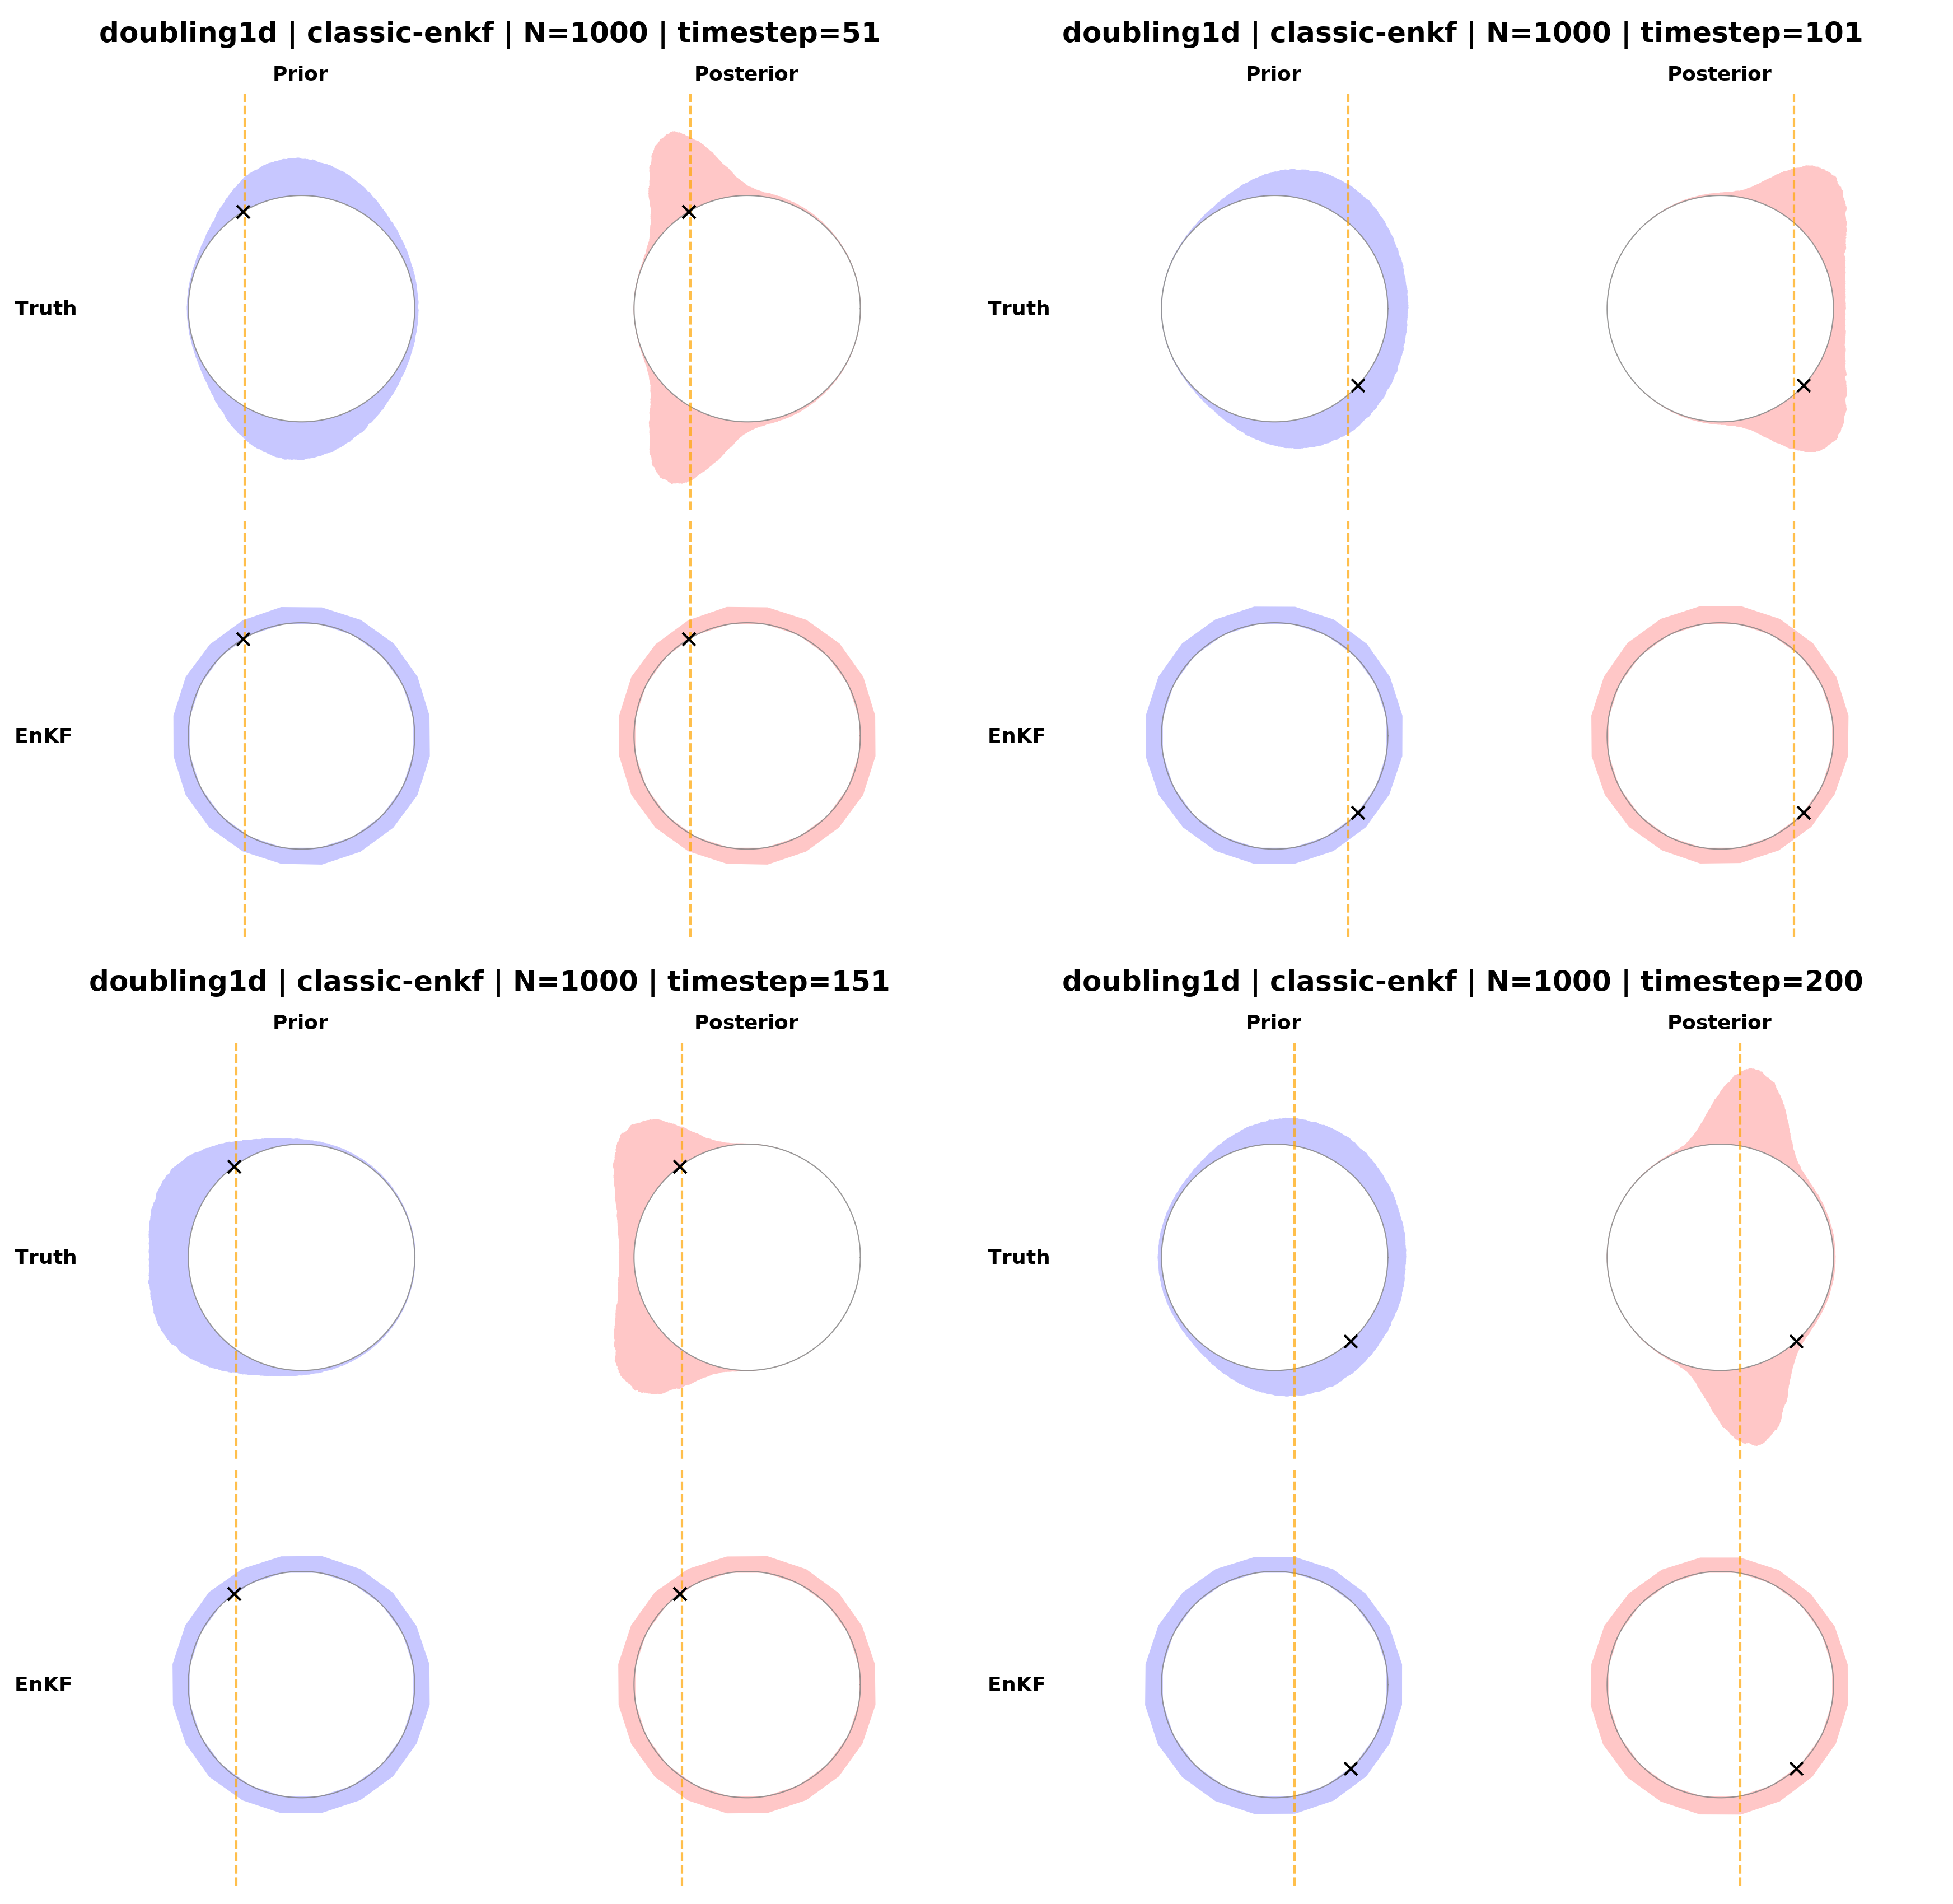

In [13]:
current_method = resolve_method_spec(METHOD_FAMILY, METHOD_NAME)
print('Current trial:')
print(' -', current_method['label'], '|', current_method['dir'])

slice_previews = build_slice_previews(method_spec=current_method)
print('\nSaved slice previews:')
print(' - grid:', slice_previews['grid_path'])
print(' - selected steps =', slice_previews['slice_steps'])
print(' - individual slice files =')
for image_path in slice_previews['image_paths']:
    print('   ', image_path)

with Image.open(slice_previews['grid_path']) as preview_im:
    display(preview_im.copy())


In [14]:
current_method = resolve_method_spec(METHOD_FAMILY, METHOD_NAME)
results = build_animation(method_spec=current_method)
print('Created GIF:')
print(' - gif_path =', results['gif_path'])
print(' - steps =', results['used_steps'][:5], '...', results['used_steps'][-5:])
print(' - pf_dir =', results['pf_dir'])
print(' - method_dir =', results['method_spec']['dir'])


Using common available steps only: {'requested_start': 1, 'requested_end': 200, 'effective_start': 2, 'effective_end': 200, 'effective_count': 199}
Created GIF:
 - gif_path = /home/bhchen/LearnKalmanGain/save/figures/doubling1d_animation/doubling1d_classic-enkf_N1000_ring_pdf_on_ring_nohist_steps2-200.gif
 - steps = [2, 3, 4, 5, 6] ... [196, 197, 198, 199, 200]
 - pf_dir = /home/bhchen/LearnKalmanGain/save/doubling1d_pf_vis
 - method_dir = /home/bhchen/LearnKalmanGain/save/benchmark_doubling1d_0.2_EnKF
